In [27]:
import pandas as pd
import glob 
import seaborn as sns
import matplotlib.pyplot as plt
import protfasta
import numpy as np
import os
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm
os.chdir("..")
import matplotlib.patches as patches


# Loading datasets

In [2]:

def return_big_df(folder_path):
    dfs = []
    for path in glob.glob(folder_path):
        # Skip empty files
        if os.path.getsize(path) == 0:
            continue
        try:
            df = pd.read_csv(path, sep="\t", header=None, index_col=0).reset_index()
            dfs.append(df)
        except pd.errors.EmptyDataError:
            # Skip files that pandas considers empty
            continue
    if dfs:
        return pd.concat(dfs, ignore_index=True)
    else:
        # Return empty DataFrame if no valid files
        return pd.DataFrame()

In [5]:
old_SFARI_TF_dbd_coords = pd.read_csv("../soto_analysis/outputs/TFs_table_proteins.txt",sep = "\t")
old_SFARI_TF_dbd_coords.head()

,Unnamed: 0,1,2,uniprotID,ENSG,ENST,DBD_coords,AD_coords,RD_coords,Bif_coords,length
0,0,NaN,NaN,O14770,ENSG00000134138,ENST00000561208,276-338,340-477,NaN,NaN,1
1,1,NaN,NaN,O60479,ENSG00000064195,ENST00000434704,129-188,"199-263,2-91",NaN,NaN,1
2,2,NaN,NaN,O75840,ENSG00000118263,ENST00000309446,NA-NA,2-101,NaN,NaN,1
3,3,NaN,NaN,O94983,ENSG00000108509,ENST00000348066,30-155,"285-468,472-581",NaN,NaN,1
4,4,NaN,NaN,O95096,ENSG00000125820,ENST00000377142,128-187,220-273,NaN,NaN,1


In [6]:
all_TFs = pd.read_csv("../soto_analysis/outputs/all_TFs_table_proteins.txt", sep = "\t")
activator_TFs = all_TFs.dropna(subset = "AD_coords")
activator_TFs

,Unnamed: 0,1,2,uniprotID,ENSG,ENST,DBD_coords,AD_coords,RD_coords,Bif_coords,length
13,13,NaN,NaN,A6NJG6,NaN,ENST00000334384,79-135,142-315,NaN,NaN,1
27,27,NaN,NaN,A8MTJ6,NaN,ENST00000428390,145-234,369-420,NaN,NaN,1
33,33,NaN,NaN,A8MYZ6,NaN,ENST00000641094,89-178,382-491,NaN,NaN,1
45,45,NaN,NaN,O00570,NaN,ENST00000330949,51-119,125-391,NaN,NaN,1
48,48,NaN,NaN,O14627,NaN,ENST00000373514,174-230,32-131,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...
1571,1571,NaN,NaN,Q9Y458,NaN,ENST00000373294,94-283,402-481,NaN,NaN,1
1582,1582,NaN,NaN,Q9Y5R6,NaN,ENST00000382276,72-118,172-251,NaN,NaN,1
1585,1585,NaN,NaN,Q9Y692,NaN,ENST00000294409,89-165,422-573,NaN,NaN,1
1587,1587,NaN,NaN,Q9Y6Q9,NaN,ENST00000371998,31-83,621-1424,NaN,NaN,1


In [7]:
zoonomia_domains = return_big_df("../soto_analysis/outputs/mutations/domains_zoonomia_all_TF_cds/*")
# Filter to activator TFs
# zoonomia_domains = zoonomia_domains[zoonomia_domains[7].isin(activator_TFs["ENST"])]
# Filter to SFARI TFs
zoonomia_domains = zoonomia_domains[zoonomia_domains[7].isin(old_SFARI_TF_dbd_coords["ENST"])]
zoonomia_domains_by_TF = zoonomia_domains.groupby([7, 3]).mean(numeric_only=True).reset_index()
zoonomia_domains_by_TF

,7,3,1,2,4,6,9,10,12,14,15,16
0,ENST00000056233,AD,2.618465e+07,2.618465e+07,NaN,1.0,2.618465e+07,2.618465e+07,1.0,2.618465e+07,2.618465e+07,1.774942
1,ENST00000056233,DBD,2.618552e+07,2.618552e+07,NaN,1.0,2.618552e+07,2.618552e+07,1.0,2.618552e+07,2.618552e+07,3.290381
2,ENST00000056233,IDR,2.617339e+07,2.617340e+07,NaN,1.0,2.617339e+07,2.617340e+07,1.0,2.617339e+07,2.617340e+07,1.730313
3,ENST00000239243,AD,1.747295e+08,1.747295e+08,NaN,1.0,1.747295e+08,1.747295e+08,1.0,1.747295e+08,1.747295e+08,4.469471
4,ENST00000239243,DBD,1.747293e+08,1.747293e+08,NaN,1.0,1.747293e+08,1.747293e+08,1.0,1.747293e+08,1.747293e+08,5.380322
...,...,...,...,...,...,...,...,...,...,...,...,...
130,ENST00000561208,DBD,3.697826e+07,3.697826e+07,NaN,-1.0,3.697826e+07,3.697826e+07,-1.0,3.697826e+07,3.697826e+07,6.151814
131,ENST00000561208,IDR,3.699815e+07,3.699815e+07,NaN,-1.0,3.699815e+07,3.699815e+07,-1.0,3.699815e+07,3.699815e+07,6.017769
132,ENST00000592199,AD,1.308877e+07,1.308877e+07,NaN,1.0,1.308877e+07,1.308877e+07,1.0,1.308877e+07,1.308877e+07,6.703129
133,ENST00000592199,DBD,1.302535e+07,1.302535e+07,NaN,1.0,1.302535e+07,1.302535e+07,1.0,1.302535e+07,1.302535e+07,6.263010


In [8]:
verteb_domains = return_big_df("/Users/sanjanakotha/Desktop/Staller_Lab/SFARI/soto_analysis/outputs/mutations/domains_100_verteb_all_TF_cds/*")
# Filter to activator TFs
# verteb_domains = verteb_domains[verteb_domains[7].isin(activator_TFs["ENST"])]
# Filter to SFARI TFs
verteb_domains = verteb_domains[verteb_domains[7].isin(old_SFARI_TF_dbd_coords["ENST"])]
verteb_domains_by_TF = verteb_domains.groupby([7, 3]).mean(numeric_only=True).reset_index()
verteb_domains_by_TF

,7,3,1,2,4,6,9,10,12,14,15,16
0,ENST00000056233,AD,2.618465e+07,2.618465e+07,NaN,1.0,2.618465e+07,2.618465e+07,1.0,2.618465e+07,2.618465e+07,1.135412
1,ENST00000056233,DBD,2.618552e+07,2.618552e+07,NaN,1.0,2.618552e+07,2.618552e+07,1.0,2.618552e+07,2.618552e+07,3.233809
2,ENST00000056233,IDR,2.617339e+07,2.617340e+07,NaN,1.0,2.617339e+07,2.617340e+07,1.0,2.617339e+07,2.617340e+07,0.857228
3,ENST00000239243,AD,1.747295e+08,1.747295e+08,NaN,1.0,1.747295e+08,1.747295e+08,1.0,1.747295e+08,1.747295e+08,3.991688
4,ENST00000239243,DBD,1.747293e+08,1.747293e+08,NaN,1.0,1.747293e+08,1.747293e+08,1.0,1.747293e+08,1.747293e+08,5.757166
...,...,...,...,...,...,...,...,...,...,...,...,...
130,ENST00000561208,DBD,3.697826e+07,3.697826e+07,NaN,-1.0,3.697826e+07,3.697826e+07,-1.0,3.697826e+07,3.697826e+07,6.759647
131,ENST00000561208,IDR,3.699815e+07,3.699815e+07,NaN,-1.0,3.699815e+07,3.699815e+07,-1.0,3.699815e+07,3.699815e+07,5.708611
132,ENST00000592199,AD,1.308877e+07,1.308877e+07,NaN,1.0,1.308877e+07,1.308877e+07,1.0,1.308877e+07,1.308877e+07,4.962744
133,ENST00000592199,DBD,1.302535e+07,1.302535e+07,NaN,1.0,1.302535e+07,1.302535e+07,1.0,1.302535e+07,1.302535e+07,6.206731


In [10]:
mtr_domains = return_big_df("../soto_analysis/outputs/mutations/domains_mtr/*")
# Filter to activator TFs
mtr_domains = mtr_domains[mtr_domains[7].isin(activator_TFs["ENST"])]
# Filter to SFARI TFs
mtr_domains = mtr_domains[mtr_domains[7].isin(old_SFARI_TF_dbd_coords["ENST"])]
mtr_domains_by_TF = mtr_domains.groupby([7, 3]).mean(numeric_only=True).reset_index()
mtr_domains_by_TF

,7,3,0,1,2,4,6,8,9,10,12,13,14,15,16
0,ENST00000056233,AD,7.0,2.618465e+07,2.618465e+07,NaN,1.0,7.0,2.618465e+07,2.618465e+07,1.0,7.0,2.618465e+07,2.618465e+07,1.011960
1,ENST00000056233,DBD,7.0,2.618552e+07,2.618552e+07,NaN,1.0,7.0,2.618552e+07,2.618552e+07,1.0,7.0,2.618552e+07,2.618552e+07,0.988435
2,ENST00000056233,IDR,7.0,2.617427e+07,2.617427e+07,NaN,1.0,7.0,2.617427e+07,2.617427e+07,1.0,7.0,2.617427e+07,2.617427e+07,0.993355
3,ENST00000239243,AD,5.0,1.747295e+08,1.747295e+08,NaN,1.0,5.0,1.747295e+08,1.747295e+08,1.0,5.0,1.747295e+08,1.747295e+08,0.926193
4,ENST00000239243,DBD,5.0,1.747293e+08,1.747293e+08,NaN,1.0,5.0,1.747293e+08,1.747293e+08,1.0,5.0,1.747293e+08,1.747293e+08,0.826027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,ENST00000561208,DBD,15.0,3.697755e+07,3.697755e+07,NaN,-1.0,15.0,3.697755e+07,3.697755e+07,-1.0,15.0,3.697755e+07,3.697755e+07,0.547530
120,ENST00000561208,IDR,15.0,3.699765e+07,3.699765e+07,NaN,-1.0,15.0,3.699765e+07,3.699765e+07,-1.0,15.0,3.699765e+07,3.699765e+07,0.917484
121,ENST00000592199,AD,19.0,1.308883e+07,1.308883e+07,NaN,1.0,19.0,1.308883e+07,1.308883e+07,1.0,19.0,1.308883e+07,1.308883e+07,0.924588
122,ENST00000592199,DBD,19.0,1.302535e+07,1.302535e+07,NaN,1.0,19.0,1.302535e+07,1.302535e+07,1.0,19.0,1.302535e+07,1.302535e+07,0.507016


# Domain comparison

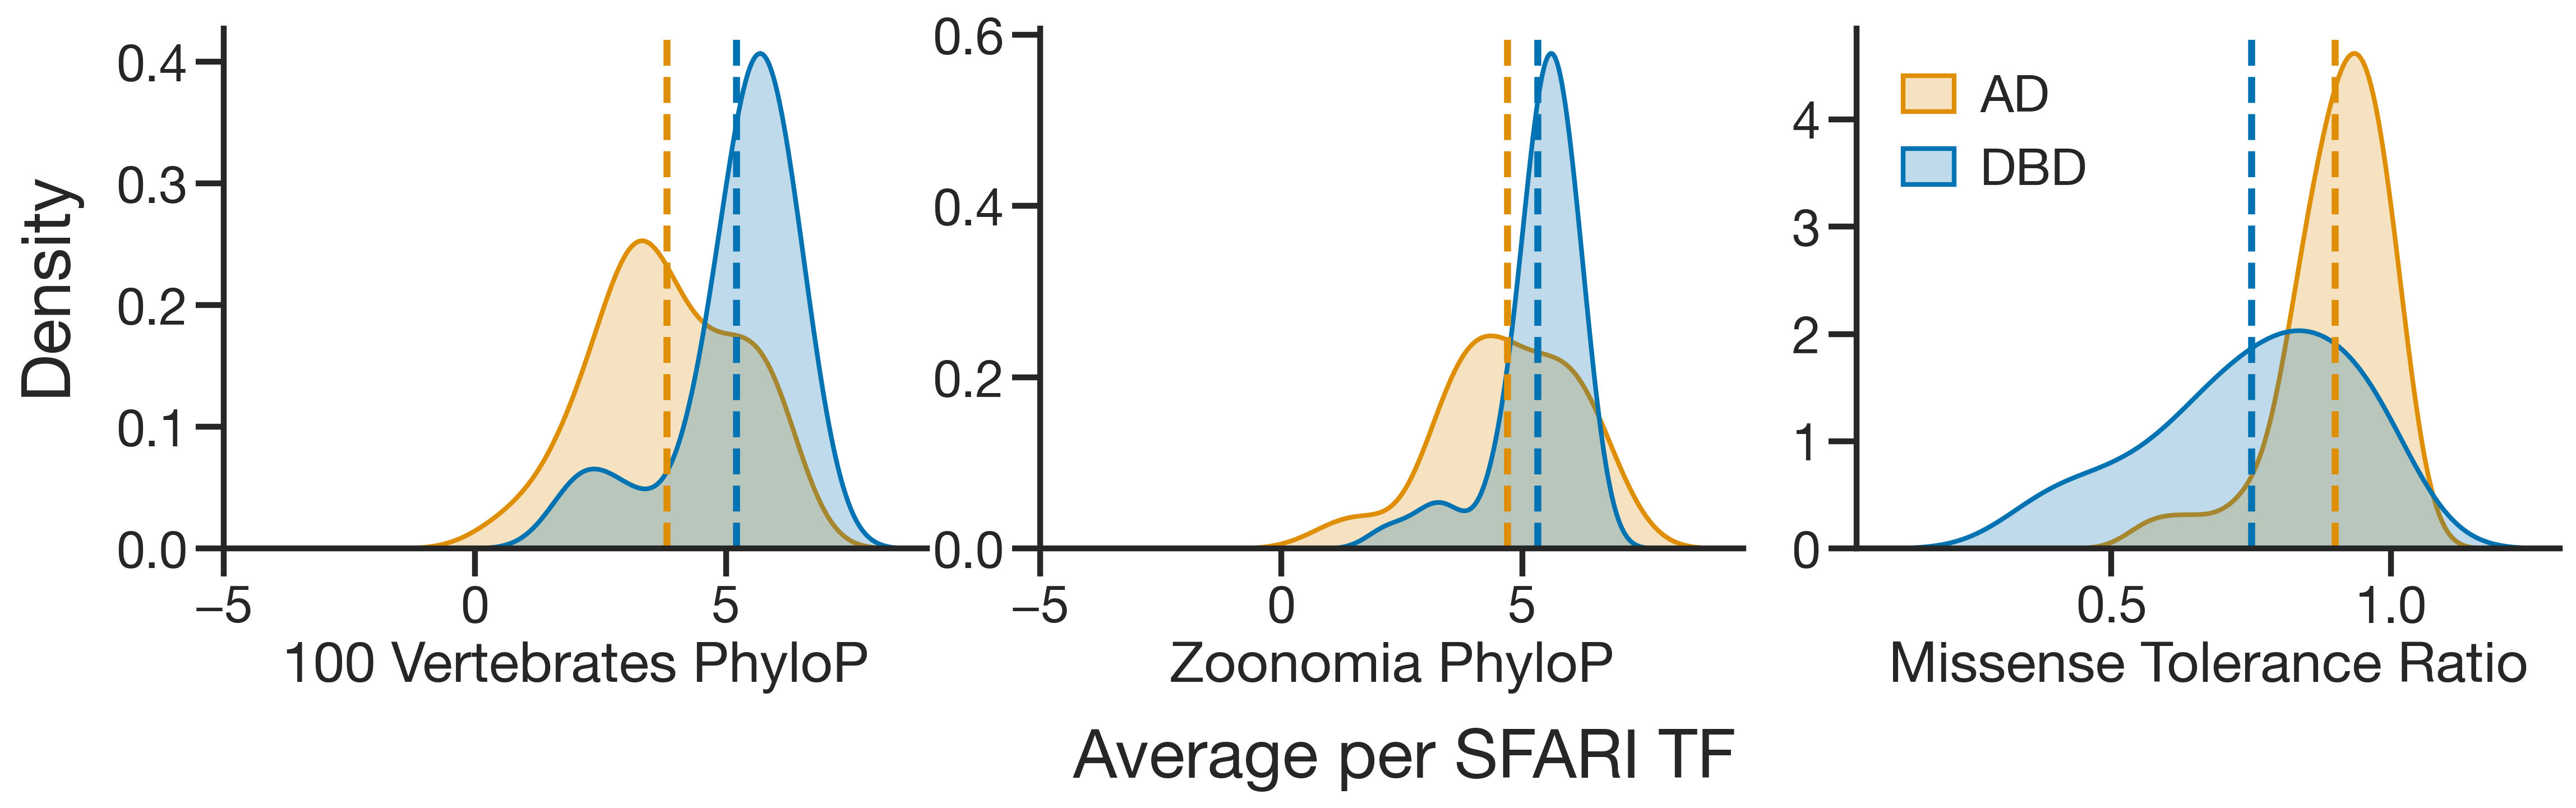

In [17]:
sns.set_context('poster')
sns.set_style('ticks')
plt.rcParams['font.family'] = 'Helvetica Neue'

color_palette = sns.color_palette('colorblind', 2)
#color_palette = ["#56B4E9", "#CC79A7", "#999999"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=300, facecolor='none')

# Plot for 100 Vertebrates PhyloP
# sns.kdeplot(verteb_domains_by_TF[verteb_domains_by_TF[3] == "IDR"][16], label="IDR", color=color_palette[1], fill=True, ax=axes[0])
# axes[0].axvline(np.mean(verteb_domains_by_TF[verteb_domains_by_TF[3] == "IDR"][16]), color=color_palette[1], linestyle="--")

sns.kdeplot(verteb_domains_by_TF[verteb_domains_by_TF[3] == "AD"][16], label="AD", color=color_palette[1], fill=True, ax=axes[0])
axes[0].axvline(np.mean(verteb_domains_by_TF[verteb_domains_by_TF[3] == "AD"][16]), color=color_palette[1], linestyle="--")

sns.kdeplot(verteb_domains_by_TF[verteb_domains_by_TF[3] == "DBD"][16], label="DBD", color=color_palette[0], fill=True, ax=axes[0])
axes[0].axvline(np.mean(verteb_domains_by_TF[verteb_domains_by_TF[3] == "DBD"][16]), color=color_palette[0], linestyle="--")

axes[0].set_xlim(-5, None)

# Plot for Zoonomia PhyloP
# sns.kdeplot(zoonomia_domains_by_TF[zoonomia_domains_by_TF[3] == "IDR"][16], label="IDR", color=color_palette[1], fill=True, ax=axes[1])
# axes[1].axvline(np.mean(zoonomia_domains_by_TF[zoonomia_domains_by_TF[3] == "IDR"][16]), color=color_palette[1], linestyle="--")

sns.kdeplot(zoonomia_domains_by_TF[zoonomia_domains_by_TF[3] == "AD"][16], label="AD", color=color_palette[1], fill=True, ax=axes[1])
axes[1].axvline(np.mean(zoonomia_domains_by_TF[zoonomia_domains_by_TF[3] == "AD"][16]), color=color_palette[1], linestyle="--")

sns.kdeplot(zoonomia_domains_by_TF[zoonomia_domains_by_TF[3] == "DBD"][16], label="DBD", color=color_palette[0], fill=True, ax=axes[1])
axes[1].axvline(np.mean(zoonomia_domains_by_TF[zoonomia_domains_by_TF[3] == "DBD"][16]), color=color_palette[0], linestyle="--")

axes[1].set_xlim(-5, None)

# Plot for Missense Tolerance Ratio
# sns.kdeplot(mtr_domains_by_TF[mtr_domains_by_TF[3] == "IDR"][16], label="IDR", color=color_palette[1], fill=True, ax=axes[2])
# axes[2].axvline(np.mean(mtr_domains_by_TF[mtr_domains_by_TF[3] == "IDR"][16]), color=color_palette[1], linestyle="--")

sns.kdeplot(mtr_domains_by_TF[mtr_domains_by_TF[3] == "AD"][16], label="AD", color=color_palette[1], fill=True, ax=axes[2])
axes[2].axvline(np.mean(mtr_domains_by_TF[mtr_domains_by_TF[3] == "AD"][16]), color=color_palette[1], linestyle="--")

sns.kdeplot(mtr_domains_by_TF[mtr_domains_by_TF[3] == "DBD"][16], label="DBD", color=color_palette[0], fill=True, ax=axes[2])
axes[2].axvline(np.mean(mtr_domains_by_TF[mtr_domains_by_TF[3] == "DBD"][16]), color=color_palette[0], linestyle="--")

axes[2].legend(loc='upper left', handletextpad=0.5, handlelength=1, frameon=False)

sns.despine()

axes[0].set_xlabel("100 Vertebrates PhyloP")
axes[1].set_xlabel("Zoonomia PhyloP")
axes[2].set_xlabel("Missense Tolerance Ratio")
fig.supxlabel("Average per SFARI TF", y = -0.03, x= 0.54)

axes[0].set_ylabel("")
axes[1].set_ylabel("")
axes[2].set_ylabel("")
fig.supylabel("Density", x= -0.01, y = 0.64)


plt.tight_layout(pad=0.1)


# TF Group comparison

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Reading in all data 

hits = ["ARX", "CAMTA2", "CASZ1", "ERG", "HIVEP3", "KDM5B", "KLF7", "KLF16", "MEIS2", "MTF1", "MYT1L", "NCOA1", "NKX2-2", "NR1D1", "NR4A2", "OTX1", "PAX5", "PAX6", "PITX1", "RORA", "TCF7L2", "TFE3", "YY1"]

lambert_TFs = pd.read_csv("../output/lambert_TFs_LOEUF_group_info.csv")
lambert_TFs

lambert_TFs["hits"] = lambert_TFs["From"].isin(hits)
lambert_TFs


# Mock data for demonstration purposes
verteb_all_TFs = return_big_df("../soto_analysis/outputs/mutations/cds_100_verteb_all_TF_cds/*")

verteb_activator_TFs = verteb_all_TFs[verteb_all_TFs[3].isin(lambert_TFs[lambert_TFs["activator"]]["transcript"])]
verteb_SFARI_activator_TFs = verteb_all_TFs[verteb_all_TFs[3].isin(lambert_TFs[lambert_TFs["sfari"] & lambert_TFs["activator"]]["transcript"])]
verteb_activator_TFs["key"] = "chr" + verteb_activator_TFs[0].astype(str) + "_" + verteb_activator_TFs[1].astype(str)

verteb_SFARI_TF_hits = verteb_all_TFs[verteb_all_TFs[3].isin(lambert_TFs[lambert_TFs["hits"]]["transcript"])]

zoonomia_all_TFs = return_big_df("../soto_analysis/outputs/mutations/cds_zoonomia_all_TF_cds/*")
zoonomia_all_TFs


zoonomia_activator_TFs = zoonomia_all_TFs[zoonomia_all_TFs[3].isin(lambert_TFs[lambert_TFs["activator"]]["transcript"])]
zoonomia_SFARI_activator_TFs = zoonomia_all_TFs[zoonomia_all_TFs[3].isin(lambert_TFs[lambert_TFs["sfari"] & lambert_TFs["activator"]]["transcript"])]
zoonomia_SFARI_TF_hits = zoonomia_all_TFs[zoonomia_all_TFs[3].isin(lambert_TFs[lambert_TFs["hits"]]["transcript"])]

activator_TFs_loeuf = lambert_TFs[lambert_TFs["transcript"].isin(activator_TFs["ENST"])]
SFARI_TFs_with_ADs = lambert_TFs[lambert_TFs["transcript"].isin(lambert_TFs[lambert_TFs["sfari"] & lambert_TFs["activator"]]["transcript"])]


/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_62718/3150595571.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  verteb_activator_TFs["key"] = "chr" + verteb_activator_TFs[0].astype(str) + "_" + verteb_activator_TFs[1].astype(str)


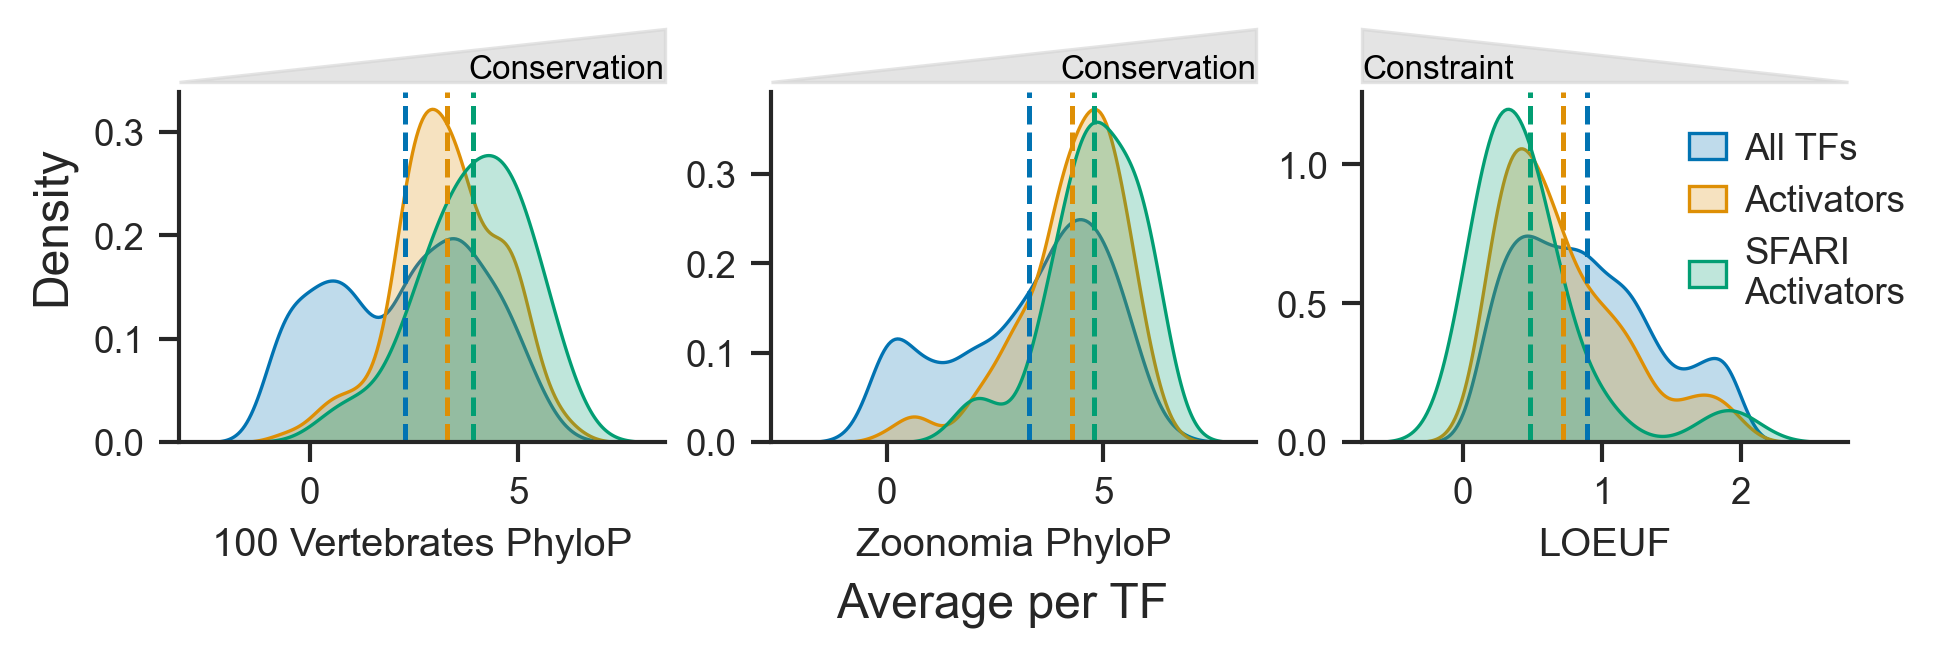

In [63]:
sns.set_context('paper')
sns.set_style('ticks')
fig, axs = plt.subplots(1, 3, figsize=(6, 2), dpi=300, facecolor='none')  # Create 3 subplots in a single column

palette = sns.color_palette('colorblind', 3)

# First subplot: 100 Vertebrates
sns.kdeplot(verteb_all_TFs[[3, 8]].groupby(3).mean()[8], label="All TFs", color=palette[0], ax=axs[0], fill=True)
sns.kdeplot(verteb_activator_TFs[[3, 8]].groupby(3).mean()[8], label="Activator TFs", color=palette[1], ax=axs[0], fill=True)
sns.kdeplot(verteb_SFARI_activator_TFs[[3, 8]].groupby(3).mean()[8], label="SFARI Activator TFs", color=palette[2], ax=axs[0], fill=True)
axs[0].axvline(verteb_all_TFs[[3, 8]].groupby(3).mean()[8].mean(), color=palette[0], linestyle='--')
axs[0].axvline(verteb_activator_TFs[[3, 8]].groupby(3).mean()[8].mean(), color=palette[1], linestyle='--')
axs[0].axvline(verteb_SFARI_activator_TFs[[3, 8]].groupby(3).mean()[8].mean(), color=palette[2], linestyle='--')
axs[0].set_xlabel("100 Vertebrates PhyloP")
sns.despine(ax=axs[0])

xmin, xmax = axs[0].get_xlim()
ymax = axs[0].get_ylim()[1]

# Triangle in axes coordinates (0–1 range)
triangle = patches.Polygon(
    [
        (0.0, 1.03),   # left base
        (1.0, 1.03),   # right base
        (1.0, 1.18),   # point on the right
    ],
    closed=True,
    transform=axs[0].transAxes,
    color="lightgray",
    alpha=0.6,
    zorder=50,
    clip_on=False        # <<< CRITICAL FIX
)

axs[0].add_patch(triangle)

# Text inside the triangle
axs[0].text(
    1, 1.02,
    "Conservation",
    transform=axs[0].transAxes,
    ha="right",
    va="bottom",
    fontsize='small',
    zorder=60,
    clip_on=False,
    color='black'
)

# Make sure the axes doesn’t cut off the top
#axs[0].set_ylim(axs[0].get_ylim()[0], axs[0].get_ylim()[1] * 1.25)

# Second subplot: Zoonomia
sns.kdeplot(zoonomia_all_TFs[[3, 8]].groupby(3).mean()[8], label="All TFs", color=palette[0], ax=axs[1], fill=True)
sns.kdeplot(zoonomia_activator_TFs[[3, 8]].groupby(3).mean()[8], label="Activator TFs", color=palette[1], ax=axs[1], fill=True)
sns.kdeplot(zoonomia_SFARI_activator_TFs[[3, 8]].groupby(3).mean()[8], label="SFARI Activator TFs", color=palette[2], ax=axs[1], fill=True)
axs[1].axvline(zoonomia_all_TFs[[3, 8]].groupby(3).mean()[8].mean(), color=palette[0], linestyle='--')
axs[1].axvline(zoonomia_activator_TFs[[3, 8]].groupby(3).mean()[8].mean(), color=palette[1], linestyle='--')
axs[1].axvline(zoonomia_SFARI_activator_TFs[[3, 8]].groupby(3).mean()[8].mean(), color=palette[2], linestyle='--')
axs[1].set_xlabel("Zoonomia PhyloP")
sns.despine(ax=axs[1])

xmin, xmax = axs[1].get_xlim()
ymax = axs[1].get_ylim()[1]  # Update to use axs[1] for ymax

# Triangle in axes coordinates (0–1 range)
triangle = patches.Polygon(
    [
        (0.0, 1.03),   # left base
        (1.0, 1.03),   # right base
        (1.0, 1.18),   # point on the right
    ],
    closed=True,
    transform=axs[1].transAxes,  # Update to use axs[1] for the triangle
    color="lightgray",
    alpha=0.6,
    zorder=50,
    clip_on=False        # <<< CRITICAL FIX
)

axs[1].add_patch(triangle)

# Text inside the triangle
axs[1].text(
    1, 1.02,
    "Conservation",
    transform=axs[1].transAxes,  # Update to use axs[1] for the text
    ha="right",
    va="bottom",
    fontsize='small',
    zorder=60,
    clip_on=False,
    color='black'
)

# Third subplot: LOEUF
sns.kdeplot(lambert_TFs["LOEUF"], color=palette[0], label="All TFs", ax=axs[2], fill=True)
sns.kdeplot(activator_TFs_loeuf["LOEUF"], color=palette[1], label="Activators", ax=axs[2], fill=True)
sns.kdeplot(SFARI_TFs_with_ADs["LOEUF"], color=palette[2], label="SFARI\nActivators", ax=axs[2], fill=True)
axs[2].axvline(lambert_TFs["LOEUF"].mean(), color=palette[0], linestyle='--')
axs[2].axvline(activator_TFs_loeuf["LOEUF"].mean(), color=palette[1], linestyle='--')
axs[2].axvline(SFARI_TFs_with_ADs["LOEUF"].mean(), color=palette[2], linestyle='--')
axs[2].set_xlabel("LOEUF")
sns.despine(ax=axs[2])
xmin, xmax = axs[2].get_xlim()
ymax = axs[2].get_ylim()[1]  # Update to use axs[2] for ymax

# Triangle in axes coordinates (0–1 range)
triangle = patches.Polygon(
    [
        (1.0, 1.03),   # right base
        (0.0, 1.03),   # left base
        (0.0, 1.18),   # point on the left
    ],
    closed=True,
    transform=axs[2].transAxes,  # Update to use axs[2] for the triangle
    color="lightgray",
    alpha=0.6,
    zorder=50,
    clip_on=False        # <<< CRITICAL FIX
)

axs[2].add_patch(triangle)

# Text inside the triangle
axs[2].text(
    0, 1.02,
    "Constraint",
    transform=axs[2].transAxes,  # Update to use axs[2] for the text
    ha="left",
    va="bottom",
    fontsize='small',
    zorder=60,
    clip_on=False,
    color='black'
)

fig.supxlabel("Average per TF", y = -0.03, x= 0.53)
fig.supylabel("Density", x= -0.01, y = 0.64)

# Add a single legend at the end
handles, labels = axs[2].get_legend_handles_labels()
fig.legend(handles, labels, ncol=1, bbox_to_anchor=(1.05, 0.85), handletextpad=0.5, handlelength=1, frameon=False)

axs[1].set_ylabel("")
axs[2].set_ylabel("")
axs[0].set_ylabel("")

plt.tight_layout(pad=0.0)  # Adjust layout to prevent overlap
plt.savefig("/Users/sanjanakotha/Library/CloudStorage/GoogleDrive-sanjana.kotha@berkeley.edu/Shared drives/StallerLabSPA/Projects/Sanjana/SFARI/Simons final report figures/figure1_conservation_constraint.png", bbox_inches='tight')
plt.show()
